# EMG Background Activity: Still vs. Moving Comparison

## Quick Run Guide

1. **Phase 0**: Run imports and constants. Set `DEFAULT_PROTOCOL` if needed.
2. **Phase 1**: Set `directory` to your session path. Run session loading, recording selection, and EMG processing cells.
3. **Phase 1b**: Run the MessageCenter loader to get event messages.
4. **Phase 2**: Run the Still/Moving parser. This cell identifies `"0"` and `"1"` messages and groups data into **Still** and **Moving** periods. Debug output will print so you can verify correctness.
5. **Phase 3**: Run the histogram comparison cell to generate overlaid histograms of EMG amplitude distributions for Still vs. Moving periods.

---

## Grouping Convention

| Message Sequence | Group     | Definition |
|-----------------|-----------|------------|
| `"0"` followed by `"1"` | **Still** | Period between a `"0"` message (start) and the next `"1"` message (end) |
| `"1"` followed by `"0"` | **Moving** | Period between a `"1"` message (start) and the next `"0"` message (end) |
| Trailing `"0"` (no following `"1"`) | **Still** | Uses data from `"0"` to end of recording |
| Trailing `"1"` (no following `"0"`) | **Moving** | Uses data from `"1"` to end of recording |

---

## Notes

- The histogram comparison (Phase 3) follows the style from `EMG_characterization_stage_Offline_Analysis.ipynb` Phase 2.
- Debug statements in Phase 2 print each detected period with timestamps, sample indices, and group assignment so you can verify the parser is working correctly.
- If your MessageCenter messages use different exact strings, adjust `STILL_MSG` and `MOVING_MSG` in Phase 0.

# Phase 0: Imports and Configuration

In [37]:
# Phase 0: Imports and Constants
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets
from open_ephys.analysis import Session
from scipy.signal import butter, lfilter
from collections import defaultdict
import scipy.stats as stats
from matplotlib.ticker import MultipleLocator, AutoMinorLocator, MaxNLocator

from helpers import *

# Override default protocol for this notebook
DEFAULT_PROTOCOL = PROTOCOL_OFFLINE

# === Still/Moving message identifiers ===
# These are the exact message text strings sent by the control system.
# A message of "0" indicates the start of a Still period (or end of Moving).
# A message of "1" indicates the start of a Moving period (or end of Still).
STILL_MSG = "0"
MOVING_MSG = "1"

print("Phase 0: imports and constants loaded.")
print(f"Default protocol: {DEFAULT_PROTOCOL}")
print(f"Still message: '{STILL_MSG}' | Moving message: '{MOVING_MSG}'")

Phase 0: imports and constants loaded.
Default protocol: Offline Filtering
Still message: '0' | Moving message: '1'


# Phase 1: Session Loading and Data Preparation

This section follows the same data loading pattern as the other EMG notebooks:
1. Set the session directory
2. Scan the experiment structure
3. Select and open a recording
4. Process the EMG signal
5. Load MessageCenter events

In [47]:
# ==== Load Session ====
# Set your session directory here
#directory = '2-16-2026/HRPilot-09_Test3_2026-02-16_16-34-56_001' 
#directory = '2-16-2026/HRPilot-08_Test3_2026-02-16_15-09-01_001'
directory = '2-16-2026/HRPilot-10_Test3_2026-02-16_17-07-15_001'

session = Session(directory)
print('Session loaded from:', directory)

Session loaded from: 2-16-2026/HRPilot-10_Test3_2026-02-16_17-07-15_001


In [48]:
# Scan experiment structure
record_node_name = "Record Node 106" if DEFAULT_PROTOCOL == PROTOCOL_ONLINE else "Record Node 111"
record_node_index = 0 if DEFAULT_PROTOCOL == PROTOCOL_ONLINE else 1
structure = scan_experiment_structure(directory, record_node_name)

# Flatten all experiment-recording pairs
flat_recordings = []
for exp_name, rec_list in structure.items():
    for rec in rec_list:
        flat_recordings.append((exp_name, rec))

print(f"Found {len(flat_recordings)} recordings across {len(structure)} experiments.")
for i, (e, r) in enumerate(flat_recordings):
    print(f"  [{i}] {e}/{r}")

Found 1 recordings across 1 experiments.
  [0] experiment1/recording1


In [ ]:
# Phase 1: Recording selection and metadata loading
from ipywidgets import Button, Output, Dropdown

try:
    rec_options = [f"{i}: {e}/{r}" for i,(e,r) in enumerate(flat_recordings)]
except Exception:
    rec_options = []

recording_dropdown = Dropdown(options=rec_options, description='Recording:')
load_recording_button = Button(description='Open Recording', button_style='primary')
rec_output = Output()


def on_open_recording(b):
    with rec_output:
        clear_output()
        if not recording_dropdown.options:
            print("No recordings discovered.")
            return
        sel = recording_dropdown.value
        idx = int(str(sel).split(':',1)[0])
        try:
            recording = session.recordnodes[record_node_index].recordings[idx]
            globals()['recording'] = recording
            print("Loaded recording:", recording)
            directory_str = recording.directory
            globals()['directory_str'] = directory_str

            parts = directory_str.split(os.sep)
            rn_name = parts[-3]
            exp_name  = parts[-2]
            rec_name   = parts[-1]
            globals()['record_node_name'] = rn_name
            globals()['experiment_name'] = exp_name
            globals()['recording_name'] = rec_name

            stream = recording.continuous[0]
            metadata = stream.metadata
            globals()['sample_rate'] = metadata.sample_rate
            globals()['num_channels'] = metadata.num_channels
            globals()['channel_names'] = metadata.channel_names

            print(f"Sample rate: {metadata.sample_rate} Hz | Channels: {metadata.num_channels}")
            print(f"Channel names: {metadata.channel_names}")

            # Update BIN_SAMPLE_COUNT based on actual sample_rate
            global BIN_SAMPLE_COUNT
            BIN_SAMPLE_COUNT = int((metadata.sample_rate / 1000) * BIN_DURATION_MS)

            # Preload full data
            timestamps = stream.timestamps
            n_timestamps = timestamps.shape[0]
            data = stream.get_samples(start_sample_index=0, end_sample_index=n_timestamps)
            globals()['timestamps'] = timestamps
            globals()['data'] = data
            print(f"Data shape: {data.shape} | Duration: {timestamps[-1] - timestamps[0]:.2f} s")

        except Exception as e:
            print("Error loading recording:", e)

load_recording_button.on_click(on_open_recording)
display(recording_dropdown, load_recording_button, rec_output)

Dropdown(description='Recording:', options=('0: experiment1/recording1',), value='0: experiment1/recording1')

Button(button_style='primary', description='Open Recording', style=ButtonStyle())

Output()

## EMG Processing

Apply bandpass filtering (offline) or use the prefiltered channel (online), then compute the
absolute-value rectified differential EMG signal.

Applied offline bandpass (100.0-1000.0 Hz) using lfilter at 5000.0 Hz


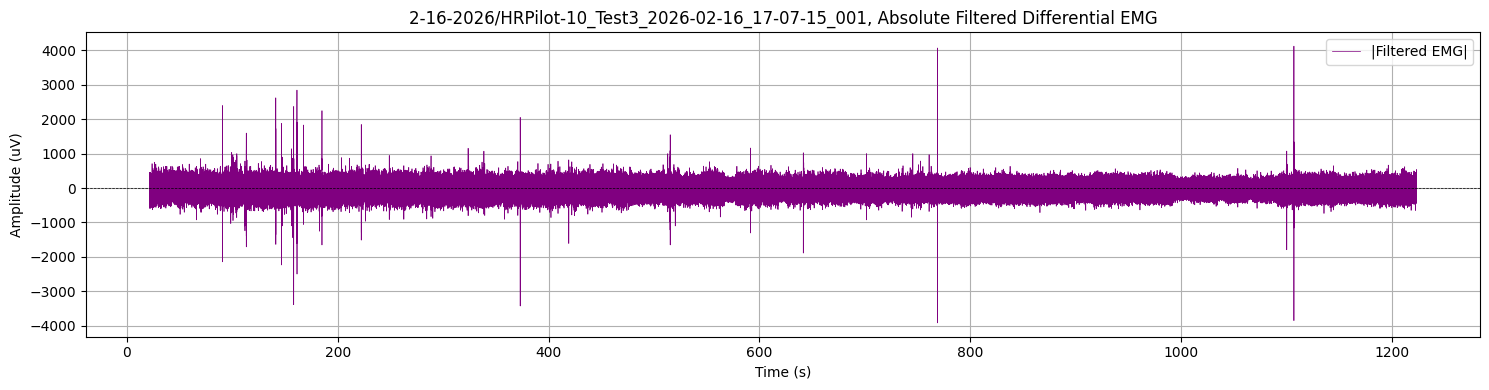

EMG signal ready: 6,009,396 samples


In [50]:
# Phase 1: EMG processing
try:
    timestamps
    data
except NameError:
    print("No recording data loaded. Please open a recording first.")
else:
    sample_rate = globals().get('sample_rate', SAMPLE_RATE_HINT)
    differential_filt, differential_emg = process_emg_signal(data, record_node_name, sample_rate)

    # Full trace plot
    plt.figure(figsize=(15, 4))
    plt.plot(timestamps, differential_filt, label="|Filtered EMG|", color='purple', linewidth=0.5)
    plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
    plt.title(f"{directory}, Absolute Filtered Differential EMG")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (uV)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(f"EMG signal ready: {len(differential_emg):,} samples")

## Load MessageCenter Events

Load the event messages from the recording's MessageCenter. We will scan these for `"0"` and `"1"` messages in Phase 2.

In [51]:
# Phase 1b: Load MessageCenter events
try:
    message_entries = load_message_center_events(
        directory_str, record_node_name, experiment_name, recording_name)
    print(f"\nFirst 20 messages:")
    for t, txt in message_entries[:20]:
        print(f"  [{t:.6f} s] {txt}")
except Exception as e:
    print("MessageCenter load error:", e)
    message_entries = []

Loaded 58 MessageCenter entries from 2-16-2026/HRPilot-10_Test3_2026-02-16_17-07-15_001\Record Node 111\experiment1\recording1\events\MessageCenter

First 20 messages:
  [23.135000 s] 1
  [115.828400 s] 0
  [125.388400 s] 1
  [160.186800 s] 0
  [167.108200 s] 1
  [175.826800 s] 0
  [179.803800 s] 1
  [275.327000 s] 0
  [285.575200 s] 1
  [303.089200 s] 0
  [307.333800 s] 1
  [330.660000 s] 0
  [367.141000 s] 1
  [375.324200 s] 0
  [377.962800 s] 1
  [380.601400 s] 0
  [392.226200 s] 1
  [402.933400 s] 0
  [417.502800 s] 1
  [421.976800 s] 0


# Phase 2: Parse Still/Moving Periods from Event Messages

This is the core logic of this notebook. We scan the MessageCenter messages for `"0"` and `"1"`
entries and define time periods:

- **Still**: starts at a `"0"` message, ends at the next `"1"` message
- **Moving**: starts at a `"1"` message, ends at the next `"0"` message
- **Trailing period**: if the last message has no matching end message, the period extends to the end of the recording

Debug statements print each detected period so you can verify correctness.

In [52]:
# Phase 2: Parse "0" and "1" messages and build Still/Moving periods

# Step 1: Extract only the "0" and "1" messages (exact match, stripped)
state_messages = []
for t, msg in message_entries:
    stripped = msg.strip()
    if stripped == STILL_MSG or stripped == MOVING_MSG:
        state_messages.append((t, stripped))

print("=" * 70)
print("PHASE 2: STILL/MOVING PERIOD PARSER")
print("=" * 70)
print(f"Found {len(state_messages)} state messages ('0' or '1') out of {len(message_entries)} total messages")
print()

if len(state_messages) == 0:
    print("WARNING: No '0' or '1' messages found in MessageCenter!")
    print("Check that your recording contains the expected state messages.")
    print("You may need to adjust STILL_MSG / MOVING_MSG in Phase 0.")
    still_periods = []
    moving_periods = []
else:
    # Debug: show all state messages
    print("[DEBUG] All state messages found:")
    for i, (t, msg) in enumerate(state_messages):
        label = "STILL-start" if msg == STILL_MSG else "MOVING-start"
        print(f"  [{i}] t={t:.6f} s | msg='{msg}' ({label})")
    print()

    # Step 2: Build periods by pairing consecutive messages
    still_periods = []   # list of (start_time, end_time)
    moving_periods = []  # list of (start_time, end_time)

    recording_end_time = float(timestamps[-1])
    recording_start_time = float(timestamps[0])

    print("[DEBUG] Recording time range: {:.6f} s to {:.6f} s".format(recording_start_time, recording_end_time))
    print()

    for i, (t_start, msg) in enumerate(state_messages):
        # Warn on consecutive duplicate messages
        if i > 0 and state_messages[i - 1][1] == msg:
            print(f"[DEBUG] WARNING: consecutive duplicate message '{msg}' at index {i} "
                  f"(t={t_start:.6f} s). Previous was at t={state_messages[i-1][0]:.6f} s.")

        # Determine the end time: the next state message, or end of recording
        if i + 1 < len(state_messages):
            t_end = state_messages[i + 1][0]
            end_source = f"next message at {t_end:.6f} s"
        else:
            # Last message: period extends to end of recording
            t_end = recording_end_time
            end_source = "end of recording (trailing period)"

        duration = t_end - t_start

        if msg == STILL_MSG:
            # "0" -> Still period: starts now, ends at next "1" (or end of recording)
            still_periods.append((t_start, t_end))
            print(f"[DEBUG] Period {i}: STILL  | {t_start:.6f} s -> {t_end:.6f} s | "
                  f"duration={duration:.3f} s | end defined by: {end_source}")
        elif msg == MOVING_MSG:
            # "1" -> Moving period: starts now, ends at next "0" (or end of recording)
            moving_periods.append((t_start, t_end))
            print(f"[DEBUG] Period {i}: MOVING | {t_start:.6f} s -> {t_end:.6f} s | "
                  f"duration={duration:.3f} s | end defined by: {end_source}")

    print()
    print("=" * 70)
    print(f"SUMMARY: {len(still_periods)} Still periods, {len(moving_periods)} Moving periods")
    print("=" * 70)

    total_still_time = sum(t_end - t_start for t_start, t_end in still_periods)
    total_moving_time = sum(t_end - t_start for t_start, t_end in moving_periods)
    print(f"Total Still time:  {total_still_time:.3f} s")
    print(f"Total Moving time: {total_moving_time:.3f} s")
    print(f"Recording duration: {recording_end_time - recording_start_time:.3f} s")

PHASE 2: STILL/MOVING PERIOD PARSER
Found 58 state messages ('0' or '1') out of 58 total messages

[DEBUG] All state messages found:
  [0] t=23.135000 s | msg='1' (MOVING-start)
  [1] t=115.828400 s | msg='0' (STILL-start)
  [2] t=125.388400 s | msg='1' (MOVING-start)
  [3] t=160.186800 s | msg='0' (STILL-start)
  [4] t=167.108200 s | msg='1' (MOVING-start)
  [5] t=175.826800 s | msg='0' (STILL-start)
  [6] t=179.803800 s | msg='1' (MOVING-start)
  [7] t=275.327000 s | msg='0' (STILL-start)
  [8] t=285.575200 s | msg='1' (MOVING-start)
  [9] t=303.089200 s | msg='0' (STILL-start)
  [10] t=307.333800 s | msg='1' (MOVING-start)
  [11] t=330.660000 s | msg='0' (STILL-start)
  [12] t=367.141000 s | msg='1' (MOVING-start)
  [13] t=375.324200 s | msg='0' (STILL-start)
  [14] t=377.962800 s | msg='1' (MOVING-start)
  [15] t=380.601400 s | msg='0' (STILL-start)
  [16] t=392.226200 s | msg='1' (MOVING-start)
  [17] t=402.933400 s | msg='0' (STILL-start)
  [18] t=417.502800 s | msg='1' (MOVING-s

## Extract EMG Samples for Each Group

Now we extract the actual EMG samples that fall within each Still and Moving period. We use
`np.searchsorted` on the timestamps array for efficient sample-index lookups.

In [53]:
# Phase 2b: Extract EMG data for each period

still_samples = []   # list of 1-D arrays
moving_samples = []  # list of 1-D arrays

print("[DEBUG] Extracting EMG samples for Still periods...")
for k, (t_start, t_end) in enumerate(still_periods):
    idx_start = np.searchsorted(timestamps, t_start, side='left')
    idx_end   = np.searchsorted(timestamps, t_end, side='right')
    segment = differential_emg[idx_start:idx_end]
    still_samples.append(segment)
    print(f"  Still period {k}: samples[{idx_start}:{idx_end}] -> {len(segment):,} samples "
          f"({(t_end - t_start):.3f} s) | mean={np.mean(segment):.2f} uV")

print()
print("[DEBUG] Extracting EMG samples for Moving periods...")
for k, (t_start, t_end) in enumerate(moving_periods):
    idx_start = np.searchsorted(timestamps, t_start, side='left')
    idx_end   = np.searchsorted(timestamps, t_end, side='right')
    segment = differential_emg[idx_start:idx_end]
    moving_samples.append(segment)
    print(f"  Moving period {k}: samples[{idx_start}:{idx_end}] -> {len(segment):,} samples "
          f"({(t_end - t_start):.3f} s) | mean={np.mean(segment):.2f} uV")

# Concatenate all samples for each group
all_still_emg = np.concatenate(still_samples) if still_samples else np.array([])
all_moving_emg = np.concatenate(moving_samples) if moving_samples else np.array([])

print()
print("=" * 70)
print(f"Total Still samples:  {len(all_still_emg):,}")
print(f"Total Moving samples: {len(all_moving_emg):,}")
if len(all_still_emg) > 0:
    print(f"Still  -> mean={np.mean(all_still_emg):.2f}, median={np.median(all_still_emg):.2f}, "
          f"std={np.std(all_still_emg):.2f} uV")
if len(all_moving_emg) > 0:
    print(f"Moving -> mean={np.mean(all_moving_emg):.2f}, median={np.median(all_moving_emg):.2f}, "
          f"std={np.std(all_moving_emg):.2f} uV")
print("=" * 70)

[DEBUG] Extracting EMG samples for Still periods...
  Still period 0: samples[471880:519681] -> 47,801 samples (9.560 s) | mean=76.70 uV
  Still period 1: samples[693672:728280] -> 34,608 samples (6.921 s) | mean=70.65 uV
  Still period 2: samples[771872:791758] -> 19,886 samples (3.977 s) | mean=70.67 uV
  Still period 3: samples[1269373:1320615] -> 51,242 samples (10.248 s) | mean=73.84 uV
  Still period 4: samples[1408184:1429408] -> 21,224 samples (4.245 s) | mean=73.77 uV
  Still period 5: samples[1546038:1728444] -> 182,406 samples (36.481 s) | mean=64.61 uV
  Still period 6: samples[1769359:1782553] -> 13,194 samples (2.639 s) | mean=64.65 uV
  Still period 7: samples[1795745:1853870] -> 58,125 samples (11.625 s) | mean=65.17 uV
  Still period 8: samples[1907405:1980253] -> 72,848 samples (14.569 s) | mean=61.14 uV
  Still period 9: samples[2002622:2015625] -> 13,003 samples (2.600 s) | mean=82.07 uV
  Still period 10: samples[2153096:2189999] -> 36,903 samples (7.380 s) | mean=

## Visualize Still/Moving Periods on the Full Trace

This plot overlays shaded regions on the full EMG trace so you can visually confirm that the
Still (blue) and Moving (red) periods were parsed correctly.

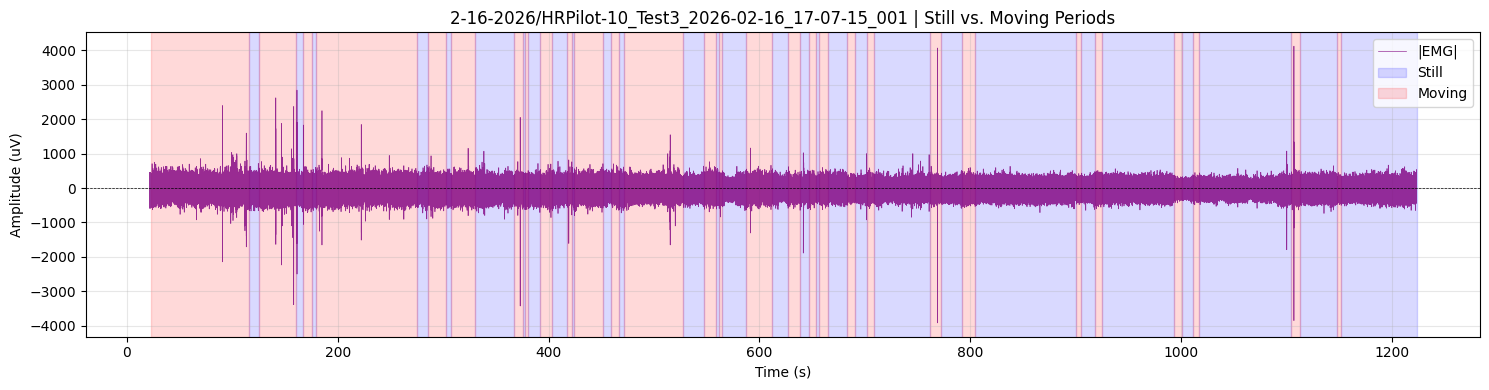

In [54]:
# Phase 2c: Full trace with Still/Moving regions overlaid
plt.figure(figsize=(15, 4))
plt.plot(timestamps, differential_filt, color='purple', linewidth=0.5, alpha=0.8, label='|EMG|')

for k, (t_start, t_end) in enumerate(still_periods):
    plt.axvspan(t_start, t_end, color='blue', alpha=0.15,
                label='Still' if k == 0 else None)

for k, (t_start, t_end) in enumerate(moving_periods):
    plt.axvspan(t_start, t_end, color='red', alpha=0.15,
                label='Moving' if k == 0 else None)

plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.title(f"{directory} | Still vs. Moving Periods")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (uV)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Phase 3: Histogram Comparison — Still vs. Moving\n\nThis section builds histograms comparing EMG amplitude distributions during Still and Moving\nperiods, matching the Phase 2 histogram style from `EMG_characterization_stage_Offline_Analysis.ipynb`:\n\n- **Overlaid histogram**: Both groups on the same axes with shared bins for direct comparison\n- **Individual histograms**: Separate full-detail plots for Still and Moving\n- **Normalized density histogram**: Probability density for shape comparison regardless of sample count\n\nAll histograms feature:\n- Quartile lines (Q1, median, Q3) with labeled text annotations above the bars\n- Tight x-axis bounds using 1st–99th percentile range (avoids outlier-stretched axes)\n- MH-style formatting: black edge color, tight y-limits, integer y-ticks

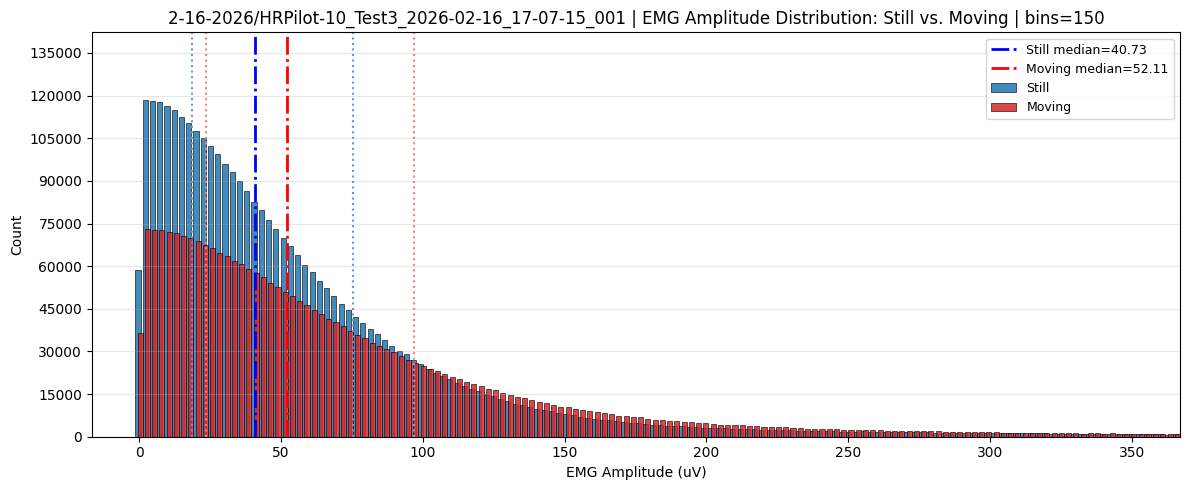


HISTOGRAM SUMMARY STATISTICS
Metric                         Still          Moving
--------------------------------------------------
n                            3365905         2635135
mean                          58.233          73.891
std                           62.546          78.255
min                            0.000           0.000
q25                           18.568          23.634
median                        40.729          52.113
q75                           75.364          97.043
max                         2847.426        4125.043


In [55]:
# Phase 3: Histogram helper + overlaid histogram — Still vs. Moving

def compute_group_stats(values, label):
    """Compute summary statistics for a group."""
    if len(values) == 0:
        print(f"  {label}: no data")
        return {}
    q25, q50, q75 = np.percentile(values, [25, 50, 75])
    return {
        'n': len(values),
        'mean': float(np.mean(values)),
        'std': float(np.std(values)),
        'min': float(np.min(values)),
        'max': float(np.max(values)),
        'q25': float(q25),
        'median': float(q50),
        'q75': float(q75),
    }


def tight_xlim(data, percentile_lo=1, percentile_hi=99, pad_frac=0.05):
    """Return (xmin, xmax) based on percentile range with padding."""
    p_lo = np.percentile(data, percentile_lo)
    p_hi = np.percentile(data, percentile_hi)
    span = p_hi - p_lo
    if span <= 0:
        span = max(1.0, abs(p_hi) * 0.1)
    return p_lo - pad_frac * span, p_hi + pad_frac * span


def add_quartile_annotations(ax, stats_dict, color_q='orange', color_med='purple',
                             y_frac=1.05, fontsize=8):
    """Add Q1, median, Q3 vertical lines with text labels (MH-style)."""
    if not stats_dict:
        return
    q25 = stats_dict['q25']
    q50 = stats_dict['median']
    q75 = stats_dict['q75']

    ax.axvline(q25, color=color_q, linestyle=':', linewidth=1.5, label=f'Q1 ({q25:.2f})')
    ax.axvline(q50, color=color_med, linestyle='-.', linewidth=1.5, label=f'Median ({q50:.2f})')
    ax.axvline(q75, color=color_q, linestyle=':', linewidth=1.5, label=f'Q3 ({q75:.2f})')

    # Text above the tallest bar
    ymax_est = ax.get_ylim()[1]
    y_text = ymax_est * y_frac
    ax.text(q25, y_text, f'Q1\n{q25:.2f}', color=color_q, ha='center', va='bottom', fontsize=fontsize)
    ax.text(q50, y_text, f'Median\n{q50:.2f}', color=color_med, ha='center', va='bottom', fontsize=fontsize)
    ax.text(q75, y_text, f'Q3\n{q75:.2f}', color=color_q, ha='center', va='bottom', fontsize=fontsize)


# Guard: need at least one group with data
if len(all_still_emg) == 0 and len(all_moving_emg) == 0:
    print("No EMG data in either group. Check Phase 2 for errors.")
else:
    # Compute stats
    still_stats = compute_group_stats(all_still_emg, 'Still')
    moving_stats = compute_group_stats(all_moving_emg, 'Moving')

    # Build shared bin edges using the 1st-99th percentile range for tight bounds
    num_bins = 150
    groups_to_merge = []
    if len(all_still_emg) > 0:
        groups_to_merge.append(all_still_emg)
    if len(all_moving_emg) > 0:
        groups_to_merge.append(all_moving_emg)
    all_data = np.concatenate(groups_to_merge)

    x_lo, x_hi = tight_xlim(all_data)
    bin_edges = np.linspace(x_lo, x_hi, num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    bin_width = bin_edges[1] - bin_edges[0]

    # === Overlaid histogram ===
    fig, ax = plt.subplots(figsize=(12, 5))

    if len(all_still_emg) > 0:
        still_hist, _ = np.histogram(all_still_emg, bins=bin_edges)
        ax.bar(bin_centers - bin_width * 0.15, still_hist, width=bin_width * 0.7,
               color='C0', alpha=0.85, edgecolor='k', linewidth=0.5, label='Still')

    if len(all_moving_emg) > 0:
        moving_hist, _ = np.histogram(all_moving_emg, bins=bin_edges)
        ax.bar(bin_centers + bin_width * 0.15, moving_hist, width=bin_width * 0.7,
               color='C3', alpha=0.85, edgecolor='k', linewidth=0.5, label='Moving')

    # Quartile annotations — Still (blue tones)
    if still_stats:
        ax.axvline(still_stats['q25'], color='cornflowerblue', linestyle=':', linewidth=1.5)
        ax.axvline(still_stats['median'], color='blue', linestyle='-.', linewidth=2,
                   label=f"Still median={still_stats['median']:.2f}")
        ax.axvline(still_stats['q75'], color='cornflowerblue', linestyle=':', linewidth=1.5)

    # Quartile annotations — Moving (red tones)
    if moving_stats:
        ax.axvline(moving_stats['q25'], color='salmon', linestyle=':', linewidth=1.5)
        ax.axvline(moving_stats['median'], color='red', linestyle='-.', linewidth=2,
                   label=f"Moving median={moving_stats['median']:.2f}")
        ax.axvline(moving_stats['q75'], color='salmon', linestyle=':', linewidth=1.5)

    ax.set_xlim(x_lo, x_hi)
    ymax = max(np.max(still_hist) if len(all_still_emg) > 0 else 0,
               np.max(moving_hist) if len(all_moving_emg) > 0 else 0)
    ax.set_ylim(0, ymax * 1.2 + 1)
    ax.set_xlabel('EMG Amplitude (uV)')
    ax.set_ylabel('Count')
    ax.set_title(f'{directory} | EMG Amplitude Distribution: Still vs. Moving | bins={num_bins}')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    plt.tight_layout()
    plt.show()

    # Print summary table
    print("\n" + "=" * 70)
    print("HISTOGRAM SUMMARY STATISTICS")
    print("=" * 70)
    print(f"{'Metric':<20} {'Still':>15} {'Moving':>15}")
    print("-" * 50)
    for key in ['n', 'mean', 'std', 'min', 'q25', 'median', 'q75', 'max']:
        s_val = still_stats.get(key, 'N/A')
        m_val = moving_stats.get(key, 'N/A')
        if isinstance(s_val, float):
            print(f"{key:<20} {s_val:>15.3f} {m_val:>15.3f}")
        else:
            print(f"{key:<20} {s_val:>15} {m_val:>15}")
    print("=" * 70)

## Individual Histograms — Still and Moving (MH-style)\n\nEach group gets its own full-detail histogram with Q1/median/Q3 text annotations above the\nbars, matching the MH recruitment curve histogram style. X-axis is tightened to the 1st–99th\npercentile range of each individual group.

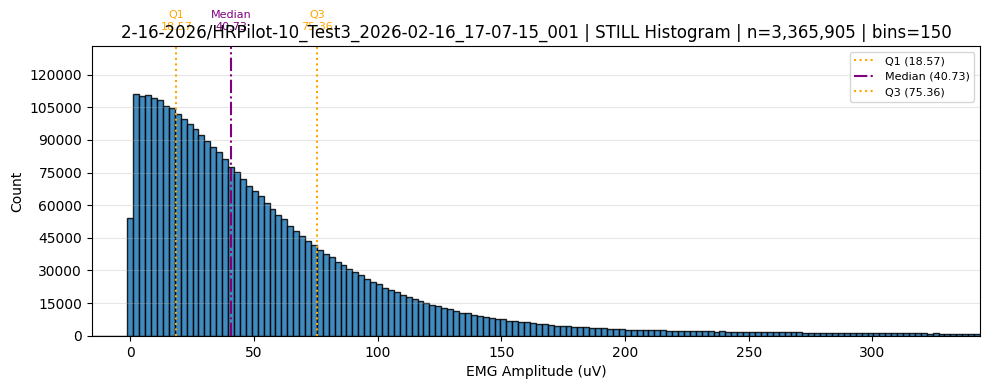

Still histogram: n=3,365,905, Q1=18.568, median=40.729, Q3=75.364, mean=58.233


In [56]:
# Phase 3b: Individual histogram — Still
if len(all_still_emg) > 0 and still_stats:
    x_lo_s, x_hi_s = tight_xlim(all_still_emg)
    edges_s = np.linspace(x_lo_s, x_hi_s, num_bins + 1)
    centers_s = (edges_s[:-1] + edges_s[1:]) / 2.0
    widths_s = edges_s[1:] - edges_s[:-1]
    hist_s, _ = np.histogram(all_still_emg, bins=edges_s)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(centers_s, hist_s, width=widths_s, align='center',
           color='C0', edgecolor='k', alpha=0.85)

    # Tight y-limit
    ymax_s = int(np.max(hist_s)) if hist_s.size > 0 else 1
    ax.set_ylim(0, ymax_s * 1.2 + 1)
    ax.set_xlim(x_lo_s, x_hi_s)

    # MH-style quartile annotations with text labels
    add_quartile_annotations(ax, still_stats, color_q='orange', color_med='purple')

    ax.set_xlabel('EMG Amplitude (uV)')
    ax.set_ylabel('Count')
    ax.set_title(f'{directory} | STILL Histogram | n={still_stats["n"]:,} | bins={num_bins}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

    print(f"Still histogram: n={still_stats['n']:,}, "
          f"Q1={still_stats['q25']:.3f}, median={still_stats['median']:.3f}, "
          f"Q3={still_stats['q75']:.3f}, mean={still_stats['mean']:.3f}")
else:
    print("No Still data to plot.")

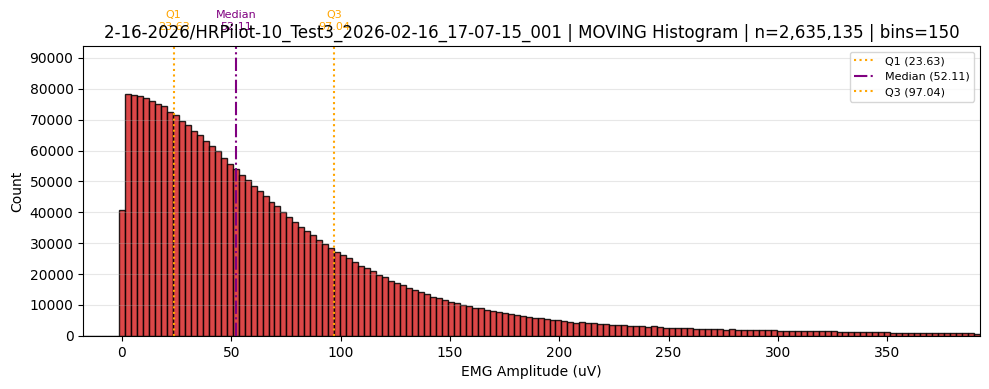

Moving histogram: n=2,635,135, Q1=23.634, median=52.113, Q3=97.043, mean=73.891


In [57]:
# Phase 3c: Individual histogram — Moving
if len(all_moving_emg) > 0 and moving_stats:
    x_lo_m, x_hi_m = tight_xlim(all_moving_emg)
    edges_m = np.linspace(x_lo_m, x_hi_m, num_bins + 1)
    centers_m = (edges_m[:-1] + edges_m[1:]) / 2.0
    widths_m = edges_m[1:] - edges_m[:-1]
    hist_m, _ = np.histogram(all_moving_emg, bins=edges_m)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(centers_m, hist_m, width=widths_m, align='center',
           color='C3', edgecolor='k', alpha=0.85)

    # Tight y-limit
    ymax_m = int(np.max(hist_m)) if hist_m.size > 0 else 1
    ax.set_ylim(0, ymax_m * 1.2 + 1)
    ax.set_xlim(x_lo_m, x_hi_m)

    # MH-style quartile annotations with text labels
    add_quartile_annotations(ax, moving_stats, color_q='orange', color_med='purple')

    ax.set_xlabel('EMG Amplitude (uV)')
    ax.set_ylabel('Count')
    ax.set_title(f'{directory} | MOVING Histogram | n={moving_stats["n"]:,} | bins={num_bins}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

    print(f"Moving histogram: n={moving_stats['n']:,}, "
          f"Q1={moving_stats['q25']:.3f}, median={moving_stats['median']:.3f}, "
          f"Q3={moving_stats['q75']:.3f}, mean={moving_stats['mean']:.3f}")
else:
    print("No Moving data to plot.")

## Normalized (Density) Histogram Comparison

Since Still and Moving periods may have very different total sample counts, this normalized
view shows probability density so the shapes can be compared directly. X-axis is tightened
to the 1st-99th percentile range of the combined data.

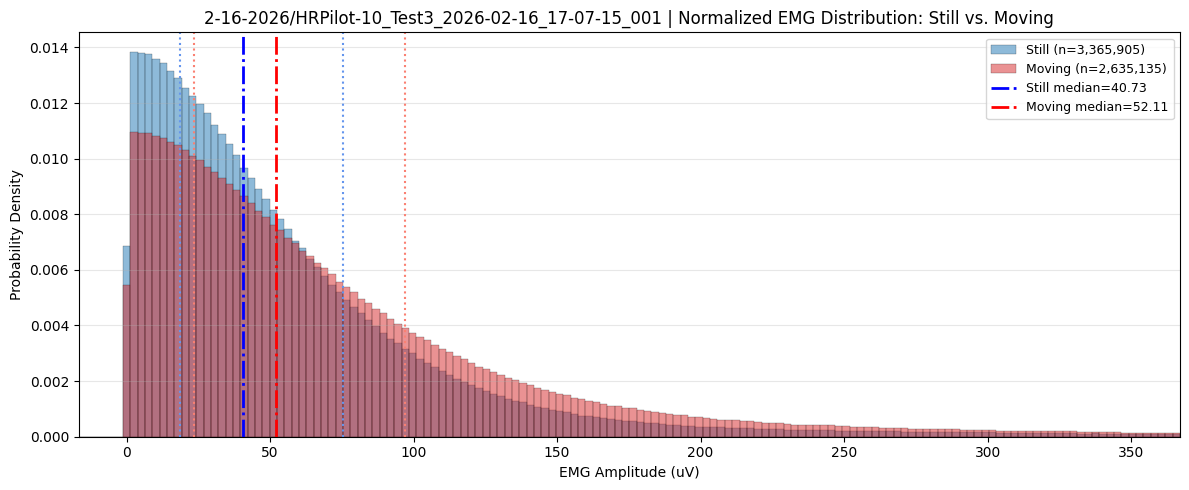

In [58]:
# Phase 3d: Normalized density histogram (tight x-axis)

if len(all_still_emg) == 0 and len(all_moving_emg) == 0:
    print("No EMG data to plot.")
else:
    fig, ax = plt.subplots(figsize=(12, 5))

    # Use the shared tight bin edges from Phase 3 main cell
    if len(all_still_emg) > 0:
        ax.hist(all_still_emg, bins=bin_edges, density=True,
                color='C0', alpha=0.5, edgecolor='k', linewidth=0.3,
                label=f'Still (n={len(all_still_emg):,})')
    if len(all_moving_emg) > 0:
        ax.hist(all_moving_emg, bins=bin_edges, density=True,
                color='C3', alpha=0.5, edgecolor='k', linewidth=0.3,
                label=f'Moving (n={len(all_moving_emg):,})')

    # Quartile lines with labels
    if still_stats:
        ax.axvline(still_stats['q25'], color='cornflowerblue', linestyle=':', linewidth=1.5)
        ax.axvline(still_stats['median'], color='blue', linestyle='-.', linewidth=2,
                   label=f"Still median={still_stats['median']:.2f}")
        ax.axvline(still_stats['q75'], color='cornflowerblue', linestyle=':', linewidth=1.5)
    if moving_stats:
        ax.axvline(moving_stats['q25'], color='salmon', linestyle=':', linewidth=1.5)
        ax.axvline(moving_stats['median'], color='red', linestyle='-.', linewidth=2,
                   label=f"Moving median={moving_stats['median']:.2f}")
        ax.axvline(moving_stats['q75'], color='salmon', linestyle=':', linewidth=1.5)

    ax.set_xlim(x_lo, x_hi)
    ax.set_xlabel('EMG Amplitude (uV)')
    ax.set_ylabel('Probability Density')
    ax.set_title(f'{directory} | Normalized EMG Distribution: Still vs. Moving')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

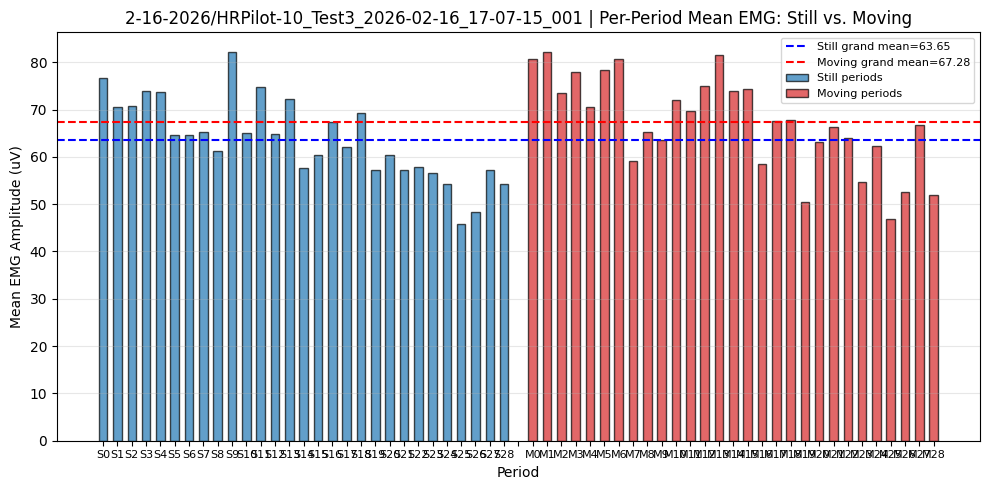


Welch's t-test (per-period means): t=-1.486, p=0.1431
  -> No statistically significant difference (p >= 0.05)


In [59]:
# Phase 3e: Per-period mean comparison
still_period_means = [float(np.mean(s)) for s in still_samples if len(s) > 0]
moving_period_means = [float(np.mean(s)) for s in moving_samples if len(s) > 0]

fig, ax = plt.subplots(figsize=(10, 5))

x_still = np.arange(len(still_period_means))
x_moving = np.arange(len(moving_period_means))
bar_width = 0.6

if len(still_period_means) > 0:
    ax.bar(x_still, still_period_means, width=bar_width, color='C0', alpha=0.7,
           edgecolor='k', label='Still periods')
    ax.axhline(np.mean(still_period_means), color='blue', linestyle='--', linewidth=1.5,
               label=f'Still grand mean={np.mean(still_period_means):.2f}')

offset = len(still_period_means) + 1
if len(moving_period_means) > 0:
    ax.bar(x_moving + offset, moving_period_means, width=bar_width, color='C3', alpha=0.7,
           edgecolor='k', label='Moving periods')
    ax.axhline(np.mean(moving_period_means), color='red', linestyle='--', linewidth=1.5,
               label=f'Moving grand mean={np.mean(moving_period_means):.2f}')

all_labels = [f'S{i}' for i in range(len(still_period_means))] + [''] + \
             [f'M{i}' for i in range(len(moving_period_means))]
all_positions = list(x_still) + [len(still_period_means)] + list(x_moving + offset)
ax.set_xticks(all_positions)
ax.set_xticklabels(all_labels, fontsize=8)

ax.set_xlabel('Period')
ax.set_ylabel('Mean EMG Amplitude (uV)')
ax.set_title(f'{directory} | Per-Period Mean EMG: Still vs. Moving')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

if len(still_period_means) >= 2 and len(moving_period_means) >= 2:
    t_stat, p_val = stats.ttest_ind(still_period_means, moving_period_means, equal_var=False)
    print(f"\nWelch's t-test (per-period means): t={t_stat:.3f}, p={p_val:.4f}")
    if p_val < 0.05:
        print("  -> Statistically significant difference (p < 0.05)")
    else:
        print("  -> No statistically significant difference (p >= 0.05)")